# Investment Portfolio Performance and Risk Analytics

**Developed by:** Eric Rathod

## Project Overview

This project analyzes the historical performance and risk of a diversified
investment portfolio using Python, SQL, and Power BI.

The project collects historical market data, calculates key investment
performance metrics, stores processed results in a SQLite database, and
prepares datasets for an interactive Power BI dashboard.

## Business Objectives

- Evaluate portfolio and individual asset performance
- Measure portfolio risk and volatility
- Compare portfolio performance against the S&P 500 benchmark
- Identify the strongest and weakest performing investments
- Automate the preparation of investment reporting data

## Tools Used

- Python
- Pandas
- NumPy
- Yahoo Finance
- SQLite
- Matplotlib
- Plotly
- Power BI

In [1]:
# Install the libraries required for this project
!pip install -q yfinance plotly


In [2]:
# Data collection and manipulation
import yfinance as yf
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# Database and file management
import sqlite3
import os
import warnings

# Display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Create folders for project outputs

folders = [
    "data",
    "database",
    "charts"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [4]:
# Define the assets included in the portfolio

portfolio = {
    "AAPL": {
        "company": "Apple",
        "sector": "Technology",
        "weight": 0.15
    },
    "MSFT": {
        "company": "Microsoft",
        "sector": "Technology",
        "weight": 0.15
    },
    "NVDA": {
        "company": "NVIDIA",
        "sector": "Technology",
        "weight": 0.10
    },
    "AMZN": {
        "company": "Amazon",
        "sector": "Consumer Discretionary",
        "weight": 0.10
    },
    "JPM": {
        "company": "JPMorgan Chase",
        "sector": "Financial Services",
        "weight": 0.15
    },
    "SPY": {
        "company": "S&P 500 ETF",
        "sector": "Broad Market",
        "weight": 0.15
    },
    "GLD": {
        "company": "Gold ETF",
        "sector": "Commodities",
        "weight": 0.10
    },
    "BND": {
        "company": "Total Bond Market ETF",
        "sector": "Fixed Income",
        "weight": 0.10
    }
}

initial_investment = 100000

print("Number of assets:", len(portfolio))
print("Total portfolio weight:", sum(asset["weight"] for asset in portfolio.values()))
print("Initial investment: $", f"{initial_investment:,.2f}")

Number of assets: 8
Total portfolio weight: 1.0
Initial investment: $ 100,000.00


In [5]:
# Convert the portfolio dictionary into a DataFrame

portfolio_df = pd.DataFrame.from_dict(portfolio, orient="index")

portfolio_df.index.name = "Ticker"
portfolio_df = portfolio_df.reset_index()

portfolio_df["Initial_Investment"] = (
    portfolio_df["weight"] * initial_investment
)

portfolio_df

,Ticker,company,sector,weight,Initial_Investment
0,AAPL,Apple,Technology,0.1500,"15,000.0000"
1,MSFT,Microsoft,Technology,0.1500,"15,000.0000"
2,NVDA,NVIDIA,Technology,0.1000,"10,000.0000"
3,AMZN,Amazon,Consumer Discretionary,0.1000,"10,000.0000"
4,JPM,JPMorgan Chase,Financial Services,0.1500,"15,000.0000"
5,SPY,S&P 500 ETF,Broad Market,0.1500,"15,000.0000"
6,GLD,Gold ETF,Commodities,0.1000,"10,000.0000"
7,BND,Total Bond Market ETF,Fixed Income,0.1000,"10,000.0000"


In [6]:
# Define the historical analysis period

start_date = "2023-01-01"
end_date = "2026-07-20"

tickers = list(portfolio.keys())

print("Assets:", tickers)
print("Analysis period:", start_date, "to", end_date)

Assets: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'JPM', 'SPY', 'GLD', 'BND']
Analysis period: 2023-01-01 to 2026-07-20


In [7]:
# Download adjusted historical closing prices

price_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

print("Market data downloaded successfully.")
print("Rows:", price_data.shape[0])
print("Columns:", price_data.shape[1])

Market data downloaded successfully.
Rows: 887
Columns: 40


In [8]:
# Extract adjusted closing prices

if isinstance(price_data.columns, pd.MultiIndex):
    closing_prices = price_data["Close"].copy()
else:
    closing_prices = price_data.copy()

closing_prices = closing_prices[tickers]

closing_prices.head()

Ticker,AAPL,MSFT,NVDA,AMZN,JPM,SPY,GLD,BND
Date,,,,,,,,
2023-01-03,122.9827,232.9483,14.2833,85.8200,123.7352,364.1340,171.0600,63.6491
2023-01-04,124.2512,222.7584,14.7163,85.1400,124.8890,366.9452,172.6700,64.0104
2023-01-05,122.9336,216.1563,14.2334,83.1200,124.8614,362.7570,170.5200,63.9398
2023-01-06,127.4568,218.7038,14.8261,86.0800,127.2506,371.0759,173.7100,64.6449
2023-01-09,127.9779,220.8331,15.5934,87.3600,126.7248,370.8655,174.1000,64.8212


In [9]:
# Check dataset structure and missing values

print("Dataset shape:", closing_prices.shape)

print("\nMissing values by asset:")
print(closing_prices.isnull().sum())

print("\nFirst available date:")
print(closing_prices.index.min())

print("\nLast available date:")
print(closing_prices.index.max())

Dataset shape: (887, 8)

Missing values by asset:
Ticker
AAPL    0
MSFT    0
NVDA    0
AMZN    0
JPM     0
SPY     0
GLD     0
BND     0
dtype: int64

First available date:
2023-01-03 00:00:00

Last available date:
2026-07-17 00:00:00


In [10]:
# Clean missing market-price values

closing_prices = closing_prices.sort_index()

# Fill small gaps using the previous available trading-day price
closing_prices = closing_prices.ffill()

# Remove any remaining rows with missing values
closing_prices = closing_prices.dropna()

print("Cleaned dataset shape:", closing_prices.shape)
print("Remaining missing values:", closing_prices.isnull().sum().sum())

Cleaned dataset shape: (887, 8)
Remaining missing values: 0


In [11]:
# Save the clean historical-price dataset

closing_prices.to_csv(
    "data/portfolio_prices.csv",
    index=True
)

print("portfolio_prices.csv saved successfully.")

portfolio_prices.csv saved successfully.


In [12]:
# Display summary statistics for historical asset prices

price_summary = closing_prices.describe().T

price_summary = price_summary.rename(
    columns={
        "count": "Trading_Days",
        "mean": "Average_Price",
        "std": "Price_Standard_Deviation",
        "min": "Minimum_Price",
        "max": "Maximum_Price"
    }
)

price_summary[
    [
        "Trading_Days",
        "Average_Price",
        "Price_Standard_Deviation",
        "Minimum_Price",
        "Maximum_Price"
    ]
].round(2)

,Trading_Days,Average_Price,Price_Standard_Deviation,Minimum_Price,Maximum_Price
Ticker,,,,,
AAPL,887.0000,213.6900,42.3400,122.9300,333.7400
MSFT,887.0000,396.0900,70.4600,216.1600,538.6600
NVDA,887.0000,113.9000,60.6300,14.2300,235.4700
AMZN,887.0000,184.0300,46.7900,83.1200,274.9900
JPM,887.0000,217.7700,68.1300,115.2300,346.9100
SPY,887.0000,545.9300,107.9400,362.7600,757.6200
GLD,887.0000,268.0900,90.1500,168.3500,495.9000
BND,887.0000,68.2500,3.2900,61.3500,73.9400


In [13]:
# Calculate daily percentage returns for each asset

daily_returns = closing_prices.pct_change().dropna()

print("Daily returns calculated successfully.")
print("Dataset shape:", daily_returns.shape)

daily_returns.head()

Daily returns calculated successfully.
Dataset shape: (886, 8)


Ticker,AAPL,MSFT,NVDA,AMZN,JPM,SPY,GLD,BND
Date,,,,,,,,
2023-01-04,0.0103,-0.0437,0.0303,-0.0079,0.0093,0.0077,0.0094,0.0057
2023-01-05,-0.0106,-0.0296,-0.0328,-0.0237,-0.0002,-0.0114,-0.0125,-0.0011
2023-01-06,0.0368,0.0118,0.0416,0.0356,0.0191,0.0229,0.0187,0.0110
2023-01-09,0.0041,0.0097,0.0518,0.0149,-0.0041,-0.0006,0.0022,0.0027
2023-01-10,0.0045,0.0076,0.0180,0.0287,0.0090,0.0070,0.0037,-0.0039


In [14]:
# Save daily returns for later SQL and Power BI use

daily_returns.to_csv(
    "data/daily_returns.csv",
    index=True
)

print("daily_returns.csv saved successfully.")

daily_returns.csv saved successfully.


In [15]:
# Create a weight series in the same ticker order as the price data

weights = pd.Series(
    {ticker: portfolio[ticker]["weight"] for ticker in tickers}
)

weights = weights[closing_prices.columns]

print("Portfolio weights:")
print(weights)

print("\nTotal weight:", weights.sum())

Portfolio weights:
Ticker
AAPL   0.1500
MSFT   0.1500
NVDA   0.1000
AMZN   0.1000
JPM    0.1500
SPY    0.1500
GLD    0.1000
BND    0.1000
dtype: float64

Total weight: 1.0


In [16]:
# Calculate the weighted daily return of the full portfolio

portfolio_daily_return = daily_returns.dot(weights)

portfolio_returns_df = pd.DataFrame({
    "Portfolio_Daily_Return": portfolio_daily_return
})

portfolio_returns_df.head()

,Portfolio_Daily_Return
Date,
2023-01-04,0.0013
2023-01-05,-0.0148
2023-01-06,0.0243
2023-01-09,0.0085
2023-01-10,0.0089


In [17]:
# Calculate cumulative portfolio performance

portfolio_returns_df["Portfolio_Cumulative_Return"] = (
    1 + portfolio_returns_df["Portfolio_Daily_Return"]
).cumprod() - 1

portfolio_returns_df["Portfolio_Value"] = (
    initial_investment
    * (1 + portfolio_returns_df["Portfolio_Cumulative_Return"])
)

portfolio_returns_df.tail()

,Portfolio_Daily_Return,Portfolio_Cumulative_Return,Portfolio_Value
Date,,,
2026-07-13,-0.0045,1.7554,"275,543.4749"
2026-07-14,0.0066,1.7736,"277,355.8317"
2026-07-15,0.0161,1.8182,"281,824.6059"
2026-07-16,-0.0041,1.8067,"280,665.3253"
2026-07-17,-0.0072,1.7866,"278,658.3589"


In [18]:
# Calculate the latest portfolio value and total profit or loss

current_portfolio_value = portfolio_returns_df["Portfolio_Value"].iloc[-1]

total_profit_loss = current_portfolio_value - initial_investment

total_return_percent = (
    total_profit_loss / initial_investment
) * 100

print("Initial investment:", f"${initial_investment:,.2f}")
print("Current portfolio value:", f"${current_portfolio_value:,.2f}")
print("Total profit/loss:", f"${total_profit_loss:,.2f}")
print("Total return:", f"{total_return_percent:.2f}%")

Initial investment: $100,000.00
Current portfolio value: $278,658.36
Total profit/loss: $178,658.36
Total return: 178.66%


In [19]:
# Calculate annualized portfolio return

trading_days = 252

average_daily_return = portfolio_daily_return.mean()

annualized_return = (
    (1 + average_daily_return) ** trading_days
) - 1

print("Annualized return:", f"{annualized_return * 100:.2f}%")

Annualized return: 35.54%


In [20]:
# Calculate annualized portfolio volatility

annualized_volatility = (
    portfolio_daily_return.std()
    * np.sqrt(trading_days)
)

print("Annualized volatility:", f"{annualized_volatility * 100:.2f}%")

Annualized volatility: 15.95%


In [21]:
# Calculate the portfolio Sharpe ratio

risk_free_rate = 0.04

sharpe_ratio = (
    annualized_return - risk_free_rate
) / annualized_volatility

print("Sharpe ratio:", round(sharpe_ratio, 2))

Sharpe ratio: 1.98


In [22]:
# Calculate portfolio drawdown

portfolio_returns_df["Running_Peak"] = (
    portfolio_returns_df["Portfolio_Value"].cummax()
)

portfolio_returns_df["Drawdown"] = (
    portfolio_returns_df["Portfolio_Value"]
    / portfolio_returns_df["Running_Peak"]
) - 1

maximum_drawdown = portfolio_returns_df["Drawdown"].min()

print("Maximum drawdown:", f"{maximum_drawdown * 100:.2f}%")

Maximum drawdown: -18.33%


In [23]:
# Save portfolio-level daily performance

portfolio_returns_df.to_csv(
    "data/portfolio_performance.csv",
    index=True
)

print("portfolio_performance.csv saved successfully.")

portfolio_performance.csv saved successfully.


In [24]:
# Create a summary table of portfolio KPIs

portfolio_kpi_summary = pd.DataFrame({
    "Metric": [
        "Initial Investment",
        "Current Portfolio Value",
        "Total Profit or Loss",
        "Total Return Percent",
        "Annualized Return Percent",
        "Annualized Volatility Percent",
        "Sharpe Ratio",
        "Maximum Drawdown Percent"
    ],
    "Value": [
        initial_investment,
        current_portfolio_value,
        total_profit_loss,
        total_return_percent,
        annualized_return * 100,
        annualized_volatility * 100,
        sharpe_ratio,
        maximum_drawdown * 100
    ]
})

portfolio_kpi_summary

,Metric,Value
0,Initial Investment,"100,000.0000"
1,Current Portfolio Value,"278,658.3589"
2,Total Profit or Loss,"178,658.3589"
3,Total Return Percent,178.6584
4,Annualized Return Percent,35.5422
5,Annualized Volatility Percent,15.9506
6,Sharpe Ratio,1.9775
7,Maximum Drawdown Percent,-18.3253


In [25]:
# Save portfolio KPI summary

portfolio_kpi_summary.to_csv(
    "data/portfolio_kpi_summary.csv",
    index=False
)

print("portfolio_kpi_summary.csv saved successfully.")

portfolio_kpi_summary.csv saved successfully.


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

In [4]:
portfolio = {
    "AAPL": {"company":"Apple","sector":"Technology","weight":0.15},
    "MSFT": {"company":"Microsoft","sector":"Technology","weight":0.15},
    "NVDA": {"company":"NVIDIA","sector":"Technology","weight":0.10},
    "AMZN": {"company":"Amazon","sector":"Consumer Discretionary","weight":0.10},
    "JPM": {"company":"JPMorgan Chase","sector":"Financial Services","weight":0.15},
    "SPY": {"company":"S&P 500 ETF","sector":"Broad Market","weight":0.15},
    "GLD": {"company":"Gold ETF","sector":"Commodities","weight":0.10},
    "BND": {"company":"Total Bond Market ETF","sector":"Fixed Income","weight":0.10}
}

tickers = list(portfolio.keys())

In [5]:
price_data = yf.download(
    tickers,
    start="2023-01-01",
    end="2026-07-20",
    auto_adjust=True,
    progress=False
)

In [6]:
closing_prices = price_data["Close"]

closing_prices.head()

Ticker,AAPL,AMZN,BND,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,,,
2023-01-03,122.982712,85.820000,63.649029,171.059998,123.735191,232.948257,14.283263,364.133942
2023-01-04,124.251183,85.139999,64.010330,172.669998,124.889030,222.758377,14.716301,366.945129
2023-01-05,122.933556,83.120003,63.939835,170.520004,124.861351,216.156311,14.233374,362.757050
2023-01-06,127.456772,86.080002,64.644867,173.710007,127.250671,218.703781,14.826057,371.075867
2023-01-09,127.977943,87.360001,64.821190,174.100006,126.724815,220.833191,15.593351,370.865448


In [7]:
# Calculate total return for each asset

asset_total_returns = (
    closing_prices.iloc[-1] / closing_prices.iloc[0]
) - 1

asset_total_returns

,0
Ticker,
AAPL,1.713715
AMZN,1.880797
BND,0.144715
GLD,1.153689
JPM,1.756694
MSFT,0.690590
NVDA,13.199136
SPY,1.041254


In [10]:
# Calculate daily returns

daily_returns = closing_prices.pct_change().dropna()

print("Daily returns created successfully.")
daily_returns.head()

Daily returns created successfully.


Ticker,AAPL,AMZN,BND,GLD,JPM,MSFT,NVDA,SPY
Date,,,,,,,,
2023-01-04,0.010314,-0.007924,0.005676,0.009412,0.009325,-0.043743,0.030318,0.007720
2023-01-05,-0.010605,-0.023726,-0.001101,-0.012451,-0.000222,-0.029638,-0.032816,-0.011413
2023-01-06,0.036794,0.035611,0.011026,0.018707,0.019136,0.011785,0.041640,0.022932
2023-01-09,0.004089,0.014870,0.002728,0.002245,-0.004132,0.009737,0.051753,-0.000567
2023-01-10,0.004456,0.028732,-0.003943,0.003676,0.008954,0.007617,0.017981,0.007013


In [11]:
# Step 29: Calculate annualized return for each asset

trading_days = 252

asset_annualized_returns = (
    (1 + daily_returns.mean()) ** trading_days
) - 1

asset_annualized_returns

,0
Ticker,
AAPL,0.372668
AMZN,0.420732
BND,0.040819
GLD,0.268671
JPM,0.370707
MSFT,0.198028
NVDA,1.388129
SPY,0.239012


In [12]:
# Step 30: Calculate annualized volatility for each asset

asset_annualized_volatility = (
    daily_returns.std() * np.sqrt(trading_days)
)

asset_annualized_volatility

,0
Ticker,
AAPL,0.257307
AMZN,0.317804
BND,0.056020
GLD,0.198347
JPM,0.232372
MSFT,0.250637
NVDA,0.486104
SPY,0.151250


In [13]:
# Step 31: Calculate Sharpe ratio for each asset

risk_free_rate = 0.04

asset_sharpe_ratios = (
    asset_annualized_returns - risk_free_rate
) / asset_annualized_volatility

asset_sharpe_ratios

,0
Ticker,
AAPL,1.292882
AMZN,1.198008
BND,0.014627
GLD,1.152885
JPM,1.423177
MSFT,0.630505
NVDA,2.773332
SPY,1.315784


In [14]:
# Step 32: Calculate maximum drawdown for each asset

asset_cumulative_growth = (1 + daily_returns).cumprod()

asset_running_peak = asset_cumulative_growth.cummax()

asset_drawdowns = (
    asset_cumulative_growth / asset_running_peak
) - 1

asset_max_drawdown = asset_drawdowns.min()

asset_max_drawdown

,0
Ticker,
AAPL,-0.333605
AMZN,-0.308766
BND,-0.071770
GLD,-0.264045
JPM,-0.244239
MSFT,-0.344984
NVDA,-0.368810
SPY,-0.187552


In [15]:
# Step 33: Create the portfolio information table

portfolio = {
    "AAPL": {"Company": "Apple", "Sector": "Technology", "Weight": 0.15},
    "MSFT": {"Company": "Microsoft", "Sector": "Technology", "Weight": 0.15},
    "NVDA": {"Company": "NVIDIA", "Sector": "Technology", "Weight": 0.10},
    "AMZN": {"Company": "Amazon", "Sector": "Consumer Discretionary", "Weight": 0.10},
    "JPM": {"Company": "JPMorgan Chase", "Sector": "Financial Services", "Weight": 0.15},
    "SPY": {"Company": "SPDR S&P 500 ETF", "Sector": "ETF", "Weight": 0.15},
    "GLD": {"Company": "SPDR Gold Shares", "Sector": "Commodity", "Weight": 0.10},
    "BND": {"Company": "Vanguard Total Bond Market ETF", "Sector": "Bond ETF", "Weight": 0.10}
}

initial_investment = 100000

portfolio_df = pd.DataFrame.from_dict(
    portfolio,
    orient="index"
)

portfolio_df.index.name = "Ticker"

portfolio_df = portfolio_df.reset_index()

portfolio_df["Initial_Investment"] = (
    portfolio_df["Weight"] * initial_investment
)

portfolio_df

,Ticker,Company,Sector,Weight,Initial_Investment
0,AAPL,Apple,Technology,0.15,15000.0
1,MSFT,Microsoft,Technology,0.15,15000.0
2,NVDA,NVIDIA,Technology,0.10,10000.0
3,AMZN,Amazon,Consumer Discretionary,0.10,10000.0
4,JPM,JPMorgan Chase,Financial Services,0.15,15000.0
5,SPY,SPDR S&P 500 ETF,ETF,0.15,15000.0
6,GLD,SPDR Gold Shares,Commodity,0.10,10000.0
7,BND,Vanguard Total Bond Market ETF,Bond ETF,0.10,10000.0


In [16]:
# Step 34: Create the final asset summary table

asset_summary = portfolio_df.copy()

asset_summary["Starting_Price"] = asset_summary["Ticker"].map(
    closing_prices.iloc[0]
)

asset_summary["Latest_Price"] = asset_summary["Ticker"].map(
    closing_prices.iloc[-1]
)

asset_summary["Total_Return_Percent"] = asset_summary["Ticker"].map(
    asset_total_returns * 100
)

asset_summary["Annualized_Return_Percent"] = asset_summary["Ticker"].map(
    asset_annualized_returns * 100
)

asset_summary["Annualized_Volatility_Percent"] = asset_summary["Ticker"].map(
    asset_annualized_volatility * 100
)

asset_summary["Sharpe_Ratio"] = asset_summary["Ticker"].map(
    asset_sharpe_ratios
)

asset_summary["Maximum_Drawdown_Percent"] = asset_summary["Ticker"].map(
    asset_max_drawdown * 100
)

asset_summary["Current_Value"] = asset_summary["Ticker"].map(
    initial_investment * asset_summary["Weight"] * (1 + asset_total_returns)
)

asset_summary["Profit_Loss"] = (
    asset_summary["Current_Value"]
    - asset_summary["Initial_Investment"]
)

asset_summary.round(2)

,Ticker,Company,Sector,Weight,Initial_Investment,Starting_Price,Latest_Price,Total_Return_Percent,Annualized_Return_Percent,Annualized_Volatility_Percent,Sharpe_Ratio,Maximum_Drawdown_Percent,Current_Value,Profit_Loss
0,AAPL,Apple,Technology,0.15,15000.0,122.98,333.74,171.37,37.27,25.73,1.29,-33.36,NaN,NaN
1,MSFT,Microsoft,Technology,0.15,15000.0,232.95,393.82,69.06,19.80,25.06,0.63,-34.50,NaN,NaN
2,NVDA,NVIDIA,Technology,0.10,10000.0,14.28,202.81,1319.91,138.81,48.61,2.77,-36.88,NaN,NaN
3,AMZN,Amazon,Consumer Discretionary,0.10,10000.0,85.82,247.23,188.08,42.07,31.78,1.20,-30.88,NaN,NaN
4,JPM,JPMorgan Chase,Financial Services,0.15,15000.0,123.74,341.10,175.67,37.07,23.24,1.42,-24.42,NaN,NaN
5,SPY,SPDR S&P 500 ETF,ETF,0.15,15000.0,364.13,743.29,104.13,23.90,15.12,1.32,-18.76,NaN,NaN
6,GLD,SPDR Gold Shares,Commodity,0.10,10000.0,171.06,368.41,115.37,26.87,19.83,1.15,-26.40,NaN,NaN
7,BND,Vanguard Total Bond Market ETF,Bond ETF,0.10,10000.0,63.65,72.86,14.47,4.08,5.60,0.01,-7.18,NaN,NaN


In [17]:
# Step 35: Correct current value and profit/loss calculations

initial_by_ticker = (
    asset_summary
    .set_index("Ticker")["Initial_Investment"]
)

current_value_by_ticker = (
    initial_by_ticker * (1 + asset_total_returns)
)

asset_summary["Current_Value"] = (
    asset_summary["Ticker"].map(current_value_by_ticker)
)

asset_summary["Profit_Loss"] = (
    asset_summary["Current_Value"]
    - asset_summary["Initial_Investment"]
)

asset_summary.round(2)

,Ticker,Company,Sector,Weight,Initial_Investment,Starting_Price,Latest_Price,Total_Return_Percent,Annualized_Return_Percent,Annualized_Volatility_Percent,Sharpe_Ratio,Maximum_Drawdown_Percent,Current_Value,Profit_Loss
0,AAPL,Apple,Technology,0.15,15000.0,122.98,333.74,171.37,37.27,25.73,1.29,-33.36,40705.72,25705.72
1,MSFT,Microsoft,Technology,0.15,15000.0,232.95,393.82,69.06,19.80,25.06,0.63,-34.50,25358.85,10358.85
2,NVDA,NVIDIA,Technology,0.10,10000.0,14.28,202.81,1319.91,138.81,48.61,2.77,-36.88,141991.36,131991.36
3,AMZN,Amazon,Consumer Discretionary,0.10,10000.0,85.82,247.23,188.08,42.07,31.78,1.20,-30.88,28807.97,18807.97
4,JPM,JPMorgan Chase,Financial Services,0.15,15000.0,123.74,341.10,175.67,37.07,23.24,1.42,-24.42,41350.40,26350.40
5,SPY,SPDR S&P 500 ETF,ETF,0.15,15000.0,364.13,743.29,104.13,23.90,15.12,1.32,-18.76,30618.81,15618.81
6,GLD,SPDR Gold Shares,Commodity,0.10,10000.0,171.06,368.41,115.37,26.87,19.83,1.15,-26.40,21536.89,11536.89
7,BND,Vanguard Total Bond Market ETF,Bond ETF,0.10,10000.0,63.65,72.86,14.47,4.08,5.60,0.01,-7.18,11447.15,1447.15


In [18]:
# Step 36: Classify each asset by volatility

def classify_risk(volatility):
    if volatility < 15:
        return "Low"
    elif volatility < 25:
        return "Medium"
    else:
        return "High"

asset_summary["Risk_Level"] = (
    asset_summary["Annualized_Volatility_Percent"]
    .apply(classify_risk)
)

asset_summary[
    [
        "Ticker",
        "Annualized_Volatility_Percent",
        "Risk_Level"
    ]
]

,Ticker,Annualized_Volatility_Percent,Risk_Level
0,AAPL,25.730725,High
1,MSFT,25.063707,High
2,NVDA,48.610446,High
3,AMZN,31.780409,High
4,JPM,23.237250,Medium
5,SPY,15.124975,Medium
6,GLD,19.834710,Medium
7,BND,5.601964,Low


In [19]:
# Step 37: Rank assets by total return

asset_summary["Performance_Rank"] = (
    asset_summary["Total_Return_Percent"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

asset_summary = asset_summary.sort_values(
    "Performance_Rank"
).reset_index(drop=True)

asset_summary.round(2)

,Ticker,Company,Sector,Weight,Initial_Investment,Starting_Price,Latest_Price,Total_Return_Percent,Annualized_Return_Percent,Annualized_Volatility_Percent,Sharpe_Ratio,Maximum_Drawdown_Percent,Current_Value,Profit_Loss,Risk_Level,Performance_Rank
0,NVDA,NVIDIA,Technology,0.10,10000.0,14.28,202.81,1319.91,138.81,48.61,2.77,-36.88,141991.36,131991.36,High,1
1,AMZN,Amazon,Consumer Discretionary,0.10,10000.0,85.82,247.23,188.08,42.07,31.78,1.20,-30.88,28807.97,18807.97,High,2
2,JPM,JPMorgan Chase,Financial Services,0.15,15000.0,123.74,341.10,175.67,37.07,23.24,1.42,-24.42,41350.40,26350.40,Medium,3
3,AAPL,Apple,Technology,0.15,15000.0,122.98,333.74,171.37,37.27,25.73,1.29,-33.36,40705.72,25705.72,High,4
4,GLD,SPDR Gold Shares,Commodity,0.10,10000.0,171.06,368.41,115.37,26.87,19.83,1.15,-26.40,21536.89,11536.89,Medium,5
5,SPY,SPDR S&P 500 ETF,ETF,0.15,15000.0,364.13,743.29,104.13,23.90,15.12,1.32,-18.76,30618.81,15618.81,Medium,6
6,MSFT,Microsoft,Technology,0.15,15000.0,232.95,393.82,69.06,19.80,25.06,0.63,-34.50,25358.85,10358.85,High,7
7,BND,Vanguard Total Bond Market ETF,Bond ETF,0.10,10000.0,63.65,72.86,14.47,4.08,5.60,0.01,-7.18,11447.15,1447.15,Low,8


In [20]:
# Step 38: Save the completed asset summary

asset_summary.to_csv(
    "asset_summary.csv",
    index=False
)

print("asset_summary.csv saved successfully.")
print("Missing values:", asset_summary.isnull().sum().sum())

asset_summary.round(2)

asset_summary.csv saved successfully.
Missing values: 0


,Ticker,Company,Sector,Weight,Initial_Investment,Starting_Price,Latest_Price,Total_Return_Percent,Annualized_Return_Percent,Annualized_Volatility_Percent,Sharpe_Ratio,Maximum_Drawdown_Percent,Current_Value,Profit_Loss,Risk_Level,Performance_Rank
0,NVDA,NVIDIA,Technology,0.10,10000.0,14.28,202.81,1319.91,138.81,48.61,2.77,-36.88,141991.36,131991.36,High,1
1,AMZN,Amazon,Consumer Discretionary,0.10,10000.0,85.82,247.23,188.08,42.07,31.78,1.20,-30.88,28807.97,18807.97,High,2
2,JPM,JPMorgan Chase,Financial Services,0.15,15000.0,123.74,341.10,175.67,37.07,23.24,1.42,-24.42,41350.40,26350.40,Medium,3
3,AAPL,Apple,Technology,0.15,15000.0,122.98,333.74,171.37,37.27,25.73,1.29,-33.36,40705.72,25705.72,High,4
4,GLD,SPDR Gold Shares,Commodity,0.10,10000.0,171.06,368.41,115.37,26.87,19.83,1.15,-26.40,21536.89,11536.89,Medium,5
5,SPY,SPDR S&P 500 ETF,ETF,0.15,15000.0,364.13,743.29,104.13,23.90,15.12,1.32,-18.76,30618.81,15618.81,Medium,6
6,MSFT,Microsoft,Technology,0.15,15000.0,232.95,393.82,69.06,19.80,25.06,0.63,-34.50,25358.85,10358.85,High,7
7,BND,Vanguard Total Bond Market ETF,Bond ETF,0.10,10000.0,63.65,72.86,14.47,4.08,5.60,0.01,-7.18,11447.15,1447.15,Low,8


In [21]:
best_asset = asset_summary.sort_values(
    "Total_Return_Percent",
    ascending=False
).iloc[0]

worst_asset = asset_summary.sort_values(
    "Total_Return_Percent"
).iloc[0]

highest_risk_asset = asset_summary.sort_values(
    "Annualized_Volatility_Percent",
    ascending=False
).iloc[0]

best_sharpe_asset = asset_summary.sort_values(
    "Sharpe_Ratio",
    ascending=False
).iloc[0]

print("ASSET PERFORMANCE SUMMARY")
print("-" * 45)

print(
    f"Best performing asset: "
    f"{best_asset['Ticker']} "
    f"({best_asset['Total_Return_Percent']:.2f}%)"
)

print(
    f"Worst performing asset: "
    f"{worst_asset['Ticker']} "
    f"({worst_asset['Total_Return_Percent']:.2f}%)"
)

print(
    f"Highest-risk asset: "
    f"{highest_risk_asset['Ticker']} "
    f"({highest_risk_asset['Annualized_Volatility_Percent']:.2f}%)"
)

print(
    f"Best risk-adjusted asset: "
    f"{best_sharpe_asset['Ticker']} "
    f"(Sharpe Ratio: {best_sharpe_asset['Sharpe_Ratio']:.2f})"
)

ASSET PERFORMANCE SUMMARY
---------------------------------------------
Best performing asset: NVDA (1319.91%)
Worst performing asset: BND (14.47%)
Highest-risk asset: NVDA (48.61%)
Best risk-adjusted asset: NVDA (Sharpe Ratio: 2.77)


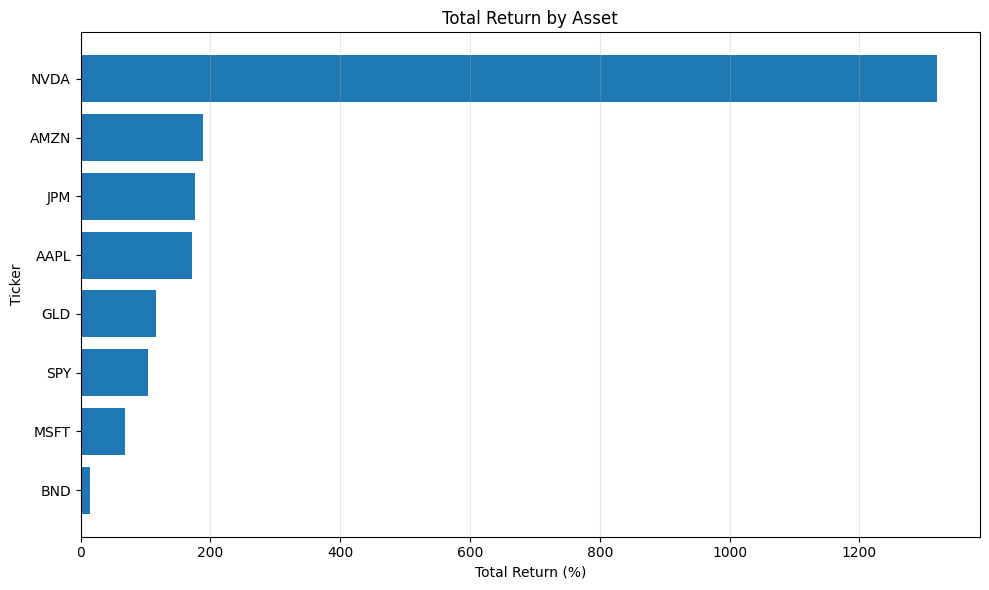

In [22]:
import matplotlib.pyplot as plt

chart_data = asset_summary.sort_values(
    "Total_Return_Percent",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    chart_data["Ticker"],
    chart_data["Total_Return_Percent"]
)

plt.title("Total Return by Asset")
plt.xlabel("Total Return (%)")
plt.ylabel("Ticker")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "asset_total_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

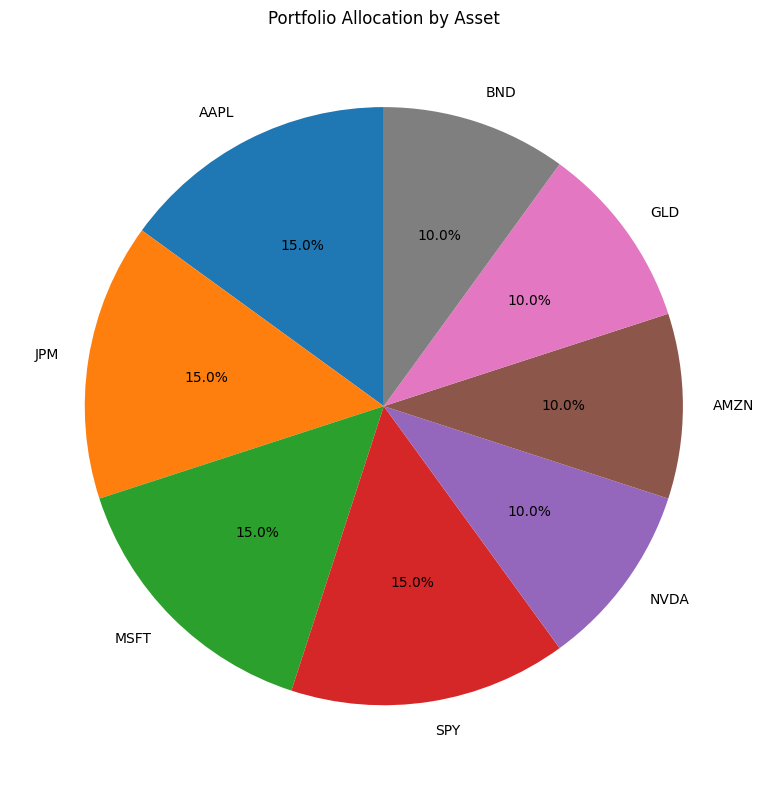

In [23]:
allocation_data = asset_summary.sort_values(
    "Weight",
    ascending=False
)

plt.figure(figsize=(8, 8))

plt.pie(
    allocation_data["Weight"],
    labels=allocation_data["Ticker"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Portfolio Allocation by Asset")
plt.tight_layout()

plt.savefig(
    "portfolio_allocation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

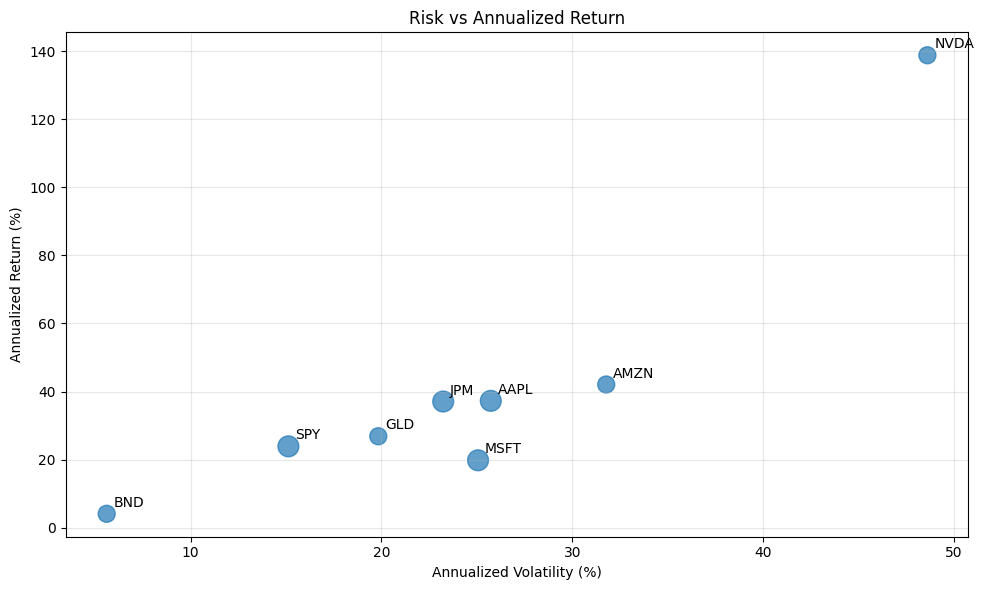

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    asset_summary["Annualized_Volatility_Percent"],
    asset_summary["Annualized_Return_Percent"],
    s=asset_summary["Weight"] * 1500,
    alpha=0.7
)

for _, row in asset_summary.iterrows():
    plt.annotate(
        row["Ticker"],
        (
            row["Annualized_Volatility_Percent"],
            row["Annualized_Return_Percent"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("Risk vs Annualized Return")
plt.xlabel("Annualized Volatility (%)")
plt.ylabel("Annualized Return (%)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "risk_vs_return.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Recreate portfolio performance metrics

weights = asset_summary.set_index("Ticker")["Weight"]

portfolio_daily_return = daily_returns.dot(weights)

portfolio_growth = (
    (1 + portfolio_daily_return).cumprod()
) * initial_investment

current_portfolio_value = portfolio_growth.iloc[-1]

total_profit_loss = (
    current_portfolio_value - initial_investment
)

total_return_percent = (
    total_profit_loss / initial_investment
) * 100

trading_days = 252

annualized_return = (
    (1 + portfolio_daily_return.mean()) ** trading_days
) - 1

annualized_volatility = (
    portfolio_daily_return.std() * np.sqrt(trading_days)
)

risk_free_rate = 0.04

sharpe_ratio = (
    annualized_return - risk_free_rate
) / annualized_volatility

print("Portfolio metrics calculated successfully.")

Portfolio metrics calculated successfully.


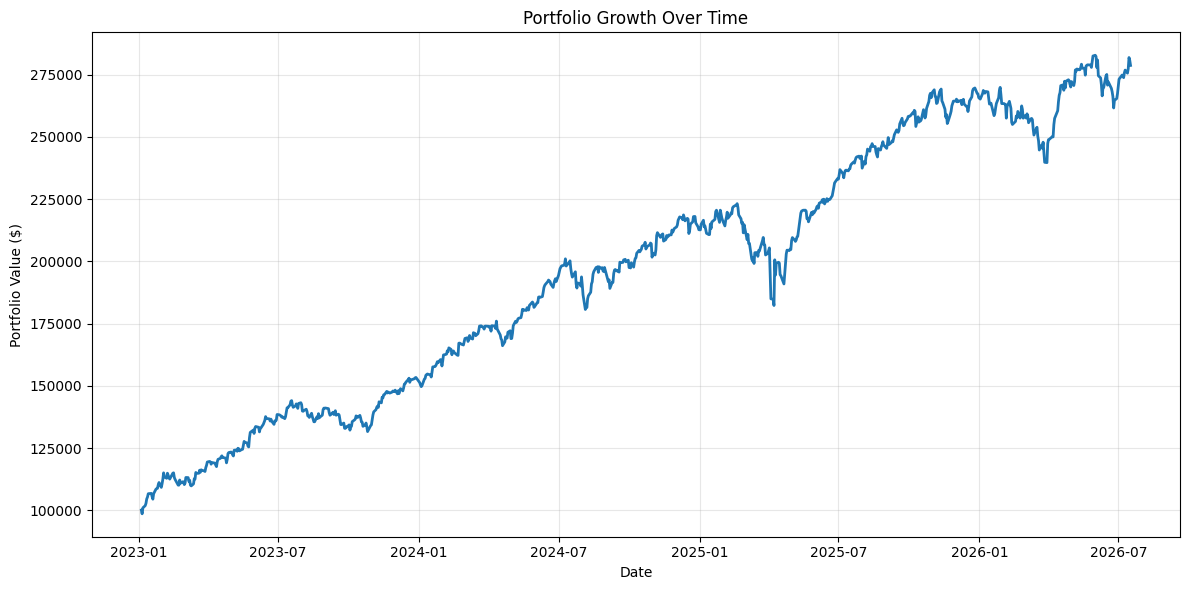

In [28]:
plt.figure(figsize=(12,6))

plt.plot(
    portfolio_growth.index,
    portfolio_growth.values,
    linewidth=2
)

plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
portfolio_kpis = pd.DataFrame({
    "Metric":[
        "Initial Investment",
        "Current Portfolio Value",
        "Profit/Loss",
        "Total Return (%)",
        "Annualized Return (%)",
        "Annualized Volatility (%)",
        "Sharpe Ratio"
    ],
    "Value":[
        initial_investment,
        current_portfolio_value,
        total_profit_loss,
        total_return_percent,
        annualized_return*100,
        annualized_volatility*100,
        sharpe_ratio
    ]
})

portfolio_kpis

,Metric,Value
0,Initial Investment,100000.000000
1,Current Portfolio Value,278658.373592
2,Profit/Loss,178658.373592
3,Total Return (%),178.658374
4,Annualized Return (%),35.542225
5,Annualized Volatility (%),15.950565
6,Sharpe Ratio,1.977499


In [30]:
# Save final datasets

asset_summary.to_csv(
    "asset_summary.csv",
    index=False
)

daily_returns.to_csv(
    "daily_returns.csv",
    index=True
)

portfolio_growth_df = pd.DataFrame({
    "Date": portfolio_growth.index,
    "Portfolio_Value": portfolio_growth.values
})

portfolio_growth_df.to_csv(
    "portfolio_growth.csv",
    index=False
)

portfolio_kpis.to_csv(
    "portfolio_kpis.csv",
    index=False
)

closing_prices.to_csv(
    "closing_prices.csv",
    index=True
)

print("All CSV files saved successfully.")

All CSV files saved successfully.


In [31]:
import sqlite3

connection = sqlite3.connect(
    "investment_portfolio.db"
)

asset_summary.to_sql(
    "asset_summary",
    connection,
    if_exists="replace",
    index=False
)

daily_returns.reset_index().to_sql(
    "daily_returns",
    connection,
    if_exists="replace",
    index=False
)

portfolio_growth_df.to_sql(
    "portfolio_growth",
    connection,
    if_exists="replace",
    index=False
)

portfolio_kpis.to_sql(
    "portfolio_kpis",
    connection,
    if_exists="replace",
    index=False
)

closing_prices.reset_index().to_sql(
    "closing_prices",
    connection,
    if_exists="replace",
    index=False
)

connection.close()

print("SQLite database created successfully.")

SQLite database created successfully.


In [32]:
import os

files = [
    "asset_summary.csv",
    "daily_returns.csv",
    "portfolio_growth.csv",
    "portfolio_kpis.csv",
    "closing_prices.csv",
    "investment_portfolio.db"
]

for file in files:
    print(
        file,
        "-",
        "Created" if os.path.exists(file) else "Missing"
    )

asset_summary.csv - Created
daily_returns.csv - Created
portfolio_growth.csv - Created
portfolio_kpis.csv - Created
closing_prices.csv - Created
investment_portfolio.db - Created


In [33]:
import shutil
import os

project_folder = "Investment_Portfolio_Analytics"

os.makedirs(project_folder, exist_ok=True)

files_to_copy = [
    "asset_summary.csv",
    "daily_returns.csv",
    "portfolio_growth.csv",
    "portfolio_kpis.csv",
    "closing_prices.csv",
    "investment_portfolio.db",
    "asset_total_returns.png",
    "portfolio_allocation.png",
    "risk_vs_return.png"
]

for file in files_to_copy:
    if os.path.exists(file):
        shutil.copy(file, project_folder)

shutil.make_archive(
    "Investment_Portfolio_Analytics",
    "zip",
    project_folder
)

print("ZIP file created successfully.")

ZIP file created successfully.


In [34]:
from google.colab import files

files.download(
    "Investment_Portfolio_Analytics.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>